# Bird Sound Classification — 114 Species (MobileNetV2 + Fine-tuning)

**Drive-backed, restart-safe pipeline.**

Every expensive step is cached to Google Drive. After a Colab restart or disconnect, re-running the full notebook only takes a couple of minutes because everything already-computed is skipped.

Pipeline:
1. Drive mount + config
2. Dataset download (cached)
3. Filter species with <4 samples + stratified split
4. Mel spectrogram generation (cached as ZIP on Drive)
5. Data generators + fixed class weights
6. Train MobileNetV2 head (checkpoint on Drive)
7. Fine-tune full model (checkpoint on Drive)
8. Evaluation + per-species metrics saved to Drive
9. Prediction on new audio


## 1. Drive mount + config

All paths, seeds, and hyperparameters live here so ablations for the paper are one-line changes.

In [1]:
# Mount Drive (idempotent — safe to run multiple times)
import os

if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive mounted.")
else:
    print("Drive already mounted.")

# ---- Drive-backed project folder ----
DRIVE_ROOT = '/content/drive/MyDrive/BirdSound114'
os.makedirs(DRIVE_ROOT, exist_ok=True)

# ---- Cache paths on Drive (survive session restarts) ----
DRIVE_KAGGLE_JSON = f'{DRIVE_ROOT}/kaggle.json'
DRIVE_SPECS_ZIP   = f'{DRIVE_ROOT}/spectrograms.zip'
DRIVE_HEAD_MODEL  = f'{DRIVE_ROOT}/mobilenet_bird_head.h5'
DRIVE_FT_MODEL    = f'{DRIVE_ROOT}/bird_finetuned_best.h5'
DRIVE_FINAL_MODEL = f'{DRIVE_ROOT}/final_bird_classifier.keras'
DRIVE_CLASS_MAP   = f'{DRIVE_ROOT}/class_indices.json'
DRIVE_HISTORY     = f'{DRIVE_ROOT}/training_history.json'
DRIVE_METRICS     = f'{DRIVE_ROOT}/final_metrics.json'
DRIVE_REPORT_CSV  = f'{DRIVE_ROOT}/per_species_accuracy.csv'

# ---- Local (fast SSD) working paths ----
DATA_DIR    = '/content/birds114'
AUDIO_DIR   = f'{DATA_DIR}/Voice of Birds/Voice of Birds'
SPECS_LOCAL = '/content/spectrograms'
KAGGLE_ZIP  = '/content/sound-of-114-species-of-birds-till-2022.zip'

# ---- Hyperparameters (change here for ablations) ----
SEED       = 42
IMG_SIZE   = (224, 224)
BATCH      = 16
SR         = 16000       # sample rate
N_MELS     = 128
N_FFT      = 2048
HOP_LENGTH = 512
EPOCHS_HEAD = 20
EPOCHS_FT   = 15
LR_HEAD    = 1e-3
LR_FT      = 1e-5
MIN_SAMPLES_PER_CLASS = 4

# ---- Reproducibility ----
import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import tensorflow as tf
    tf.random.set_seed(SEED)
except Exception:
    pass

print(f"Drive project root: {DRIVE_ROOT}")
print(f"Seed: {SEED}")


Mounted at /content/drive
Drive mounted.
Drive project root: /content/drive/MyDrive/BirdSound114
Seed: 42


## 2. Install dependencies

In [2]:
!pip install librosa tensorflow matplotlib seaborn audiomentations pandas --quiet

import tensorflow as tf
import librosa, librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, gc, json, time, zipfile, shutil
from glob import glob
from tqdm.auto import tqdm
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, f1_score

print("TF version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 18.8 MB/s eta 0:00:00
TF version: 2.20.0
GPU available: True


## 3. Dataset download — guarded

Sequence:
- If the spectrograms ZIP is already on Drive, we can skip the entire audio download step (spectrograms are all we need for training).
- Otherwise, set up Kaggle credentials from Drive (or upload once) and download the dataset.


In [3]:
# --- Fast path: if spectrograms are already cached on Drive, we can skip everything below ---
SPECS_ALREADY_CACHED = os.path.exists(DRIVE_SPECS_ZIP)

if SPECS_ALREADY_CACHED:
    print(f" Spectrograms already cached on Drive: {DRIVE_SPECS_ZIP}")
    print("  → Skipping Kaggle download.")
else:
    print("Spectrograms not cached — will need Kaggle dataset.")

    # --- Kaggle credentials setup ---
    kaggle_home = os.path.expanduser('~/.kaggle/kaggle.json')
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

    if os.path.exists(DRIVE_KAGGLE_JSON):
        shutil.copy(DRIVE_KAGGLE_JSON, kaggle_home)
        print(" kaggle.json restored from Drive.")
    elif os.path.exists(kaggle_home):
        print(" kaggle.json already in place.")
    else:
        print("Upload your kaggle.json (one-time — will be saved to Drive):")
        from google.colab import files
        uploaded = files.upload()
        shutil.copy('kaggle.json', kaggle_home)
        shutil.copy('kaggle.json', DRIVE_KAGGLE_JSON)
        print(" kaggle.json saved to Drive for future sessions.")

    os.chmod(kaggle_home, 0o600)

    # --- Download (skip if zip present locally) ---
    if not os.path.exists(KAGGLE_ZIP):
        print("Downloading dataset from Kaggle...")
        !kaggle datasets download -d soumendraprasad/sound-of-114-species-of-birds-till-2022
    else:
        print(" Kaggle zip already present locally.")

    # --- Extract (skip if already extracted) ---
    if not os.path.exists(AUDIO_DIR):
        print("Extracting dataset...")
        !unzip -q -o sound-of-114-species-of-birds-till-2022.zip -d {DATA_DIR}
    else:
        print(" Dataset already extracted.")


 Spectrograms already cached on Drive: /content/drive/MyDrive/BirdSound114/spectrograms.zip
  → Skipping Kaggle download.


## 4. Filter species (<4 samples) + safe stratified split

Rationale: some species only have 1–3 audio files → stratified 80/10/10 split becomes impossible. We drop those species (a common preprocessing choice; documented in the paper as a limitation).

In [4]:
if not SPECS_ALREADY_CACHED:
    ALL_FILES = glob(f"{AUDIO_DIR}/**/*.mp3", recursive=True) + \
                glob(f"{AUDIO_DIR}/**/*.wav", recursive=True)

    labels_raw = [p.split("/")[-2].lower().strip() for p in ALL_FILES]
    df = pd.DataFrame({"path": ALL_FILES, "label": labels_raw})

    counts = df["label"].value_counts()
    dropped = counts[counts < MIN_SAMPLES_PER_CLASS]
    valid_species = counts[counts >= MIN_SAMPLES_PER_CLASS].index

    df = df[df["label"].isin(valid_species)].reset_index(drop=True)

    print(f"Total audio files (original): {len(ALL_FILES)}")
    print(f"Species dropped (<{MIN_SAMPLES_PER_CLASS} samples): {len(dropped)}")
    print(f"Final species count: {len(valid_species)}")
    print(f"Final dataset size: {len(df)}")

    # Encode labels
    classes = sorted(df["label"].unique())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["label_idx"] = df["label"].map(class_to_idx)

    X = df["path"].values
    y = df["label_idx"].values

    # Safe stratified split with fallback
    def safe_split(X, y):
        try:
            X_train, X_temp, y_train, y_temp = train_test_split(
                X, y, test_size=0.20, stratify=y, random_state=SEED
            )
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
            )
            print("Stratified 80/10/10 split successful.")
        except ValueError:
            print(" Stratified split failed — falling back to random 80/10/10.")
            X_train, X_temp, y_train, y_temp = train_test_split(
                X, y, test_size=0.20, shuffle=True, random_state=SEED
            )
            X_val, X_test, y_val, y_test = train_test_split(
                X_temp, y_temp, test_size=0.50, shuffle=True, random_state=SEED
            )
        return X_train, X_val, X_test, y_train, y_val, y_test

    X_train, X_val, X_test, y_train, y_val, y_test = safe_split(X, y)
    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
else:
    print("Skipped — using cached spectrograms.")


Skipped — using cached spectrograms.


## 5. Mel spectrogram generation

RAM-safe: uses PIL directly instead of matplotlib (matplotlib crashes RAM at scale).
Guarded: skips if spectrograms ZIP is already on Drive.

In [5]:
def audio_to_mel_spec(audio_path, save_path):
    try:
        y, sr = librosa.load(audio_path, sr=SR, mono=True)
        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_norm = 255 * (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
        mel_norm = mel_norm.astype(np.uint8)
        img = Image.fromarray(mel_norm).convert("L").resize(IMG_SIZE)
        img.save(save_path)
        return True
    except Exception as e:
        print(f"[error] {audio_path}: {e}")
        return False


def generate_specs_chunked(file_paths, output_dir, chunk=200):
    os.makedirs(output_dir, exist_ok=True)
    total = len(file_paths)
    generated = 0
    missing = []
    start = time.time()

    for i in range(0, total, chunk):
        batch = file_paths[i:i+chunk]
        for path in tqdm(batch, desc=f"{os.path.basename(output_dir)} {i}-{i+len(batch)}", leave=False):
            cls = path.split("/")[-2].lower().strip()
            cls_dir = os.path.join(output_dir, cls)
            os.makedirs(cls_dir, exist_ok=True)
            fname = os.path.basename(path).replace(".mp3", ".png").replace(".wav", ".png")
            save_path = os.path.join(cls_dir, fname)
            if not os.path.exists(save_path):
                ok = audio_to_mel_spec(path, save_path)
                if ok:
                    generated += 1
                else:
                    missing.append(path)
        gc.collect()

    print(f"Done → {output_dir} | generated {generated} | missing {len(missing)} | {(time.time()-start)/60:.1f} min")
    return missing


def zip_folder(folder_path, zip_path):
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(folder_path):
            for f in files:
                full = os.path.join(root, f)
                rel = os.path.relpath(full, folder_path)
                zf.write(full, rel)
    print(f" Zipped to {zip_path}")


### 5a. Generate spectrograms OR restore from Drive cache

In [6]:
if os.path.exists(DRIVE_SPECS_ZIP):
    # Restore from Drive
    if not (os.path.exists(f"{SPECS_LOCAL}/train") and os.path.exists(f"{SPECS_LOCAL}/val") and os.path.exists(f"{SPECS_LOCAL}/test")):
        print(f"Restoring spectrograms from Drive: {DRIVE_SPECS_ZIP}")
        os.makedirs(SPECS_LOCAL, exist_ok=True)
        !unzip -q -o "{DRIVE_SPECS_ZIP}" -d "{SPECS_LOCAL}"
        print(" Spectrograms restored from Drive.")
    else:
        print(" Spectrograms already present locally.")
else:
    print("Generating spectrograms from scratch...")
    missing_train = generate_specs_chunked(X_train, f"{SPECS_LOCAL}/train")
    missing_val   = generate_specs_chunked(X_val,   f"{SPECS_LOCAL}/val")
    missing_test  = generate_specs_chunked(X_test,  f"{SPECS_LOCAL}/test")

    print(f"\nMissing — train: {len(missing_train)} | val: {len(missing_val)} | test: {len(missing_test)}")

    # Cache to Drive so we never regenerate
    print("\nZipping and caching to Drive...")
    zip_folder(SPECS_LOCAL, DRIVE_SPECS_ZIP)
    print(" Cached. Future sessions will skip generation entirely.")


Restoring spectrograms from Drive: /content/drive/MyDrive/BirdSound114/spectrograms.zip
 Spectrograms restored from Drive.


## 6. Data generators

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = f"{SPECS_LOCAL}/train"
VAL_DIR   = f"{SPECS_LOCAL}/val"
TEST_DIR  = f"{SPECS_LOCAL}/test"

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

test_aug = ImageDataGenerator(rescale=1./255)

# Detect class list from training folder
tmp_gen = test_aug.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", shuffle=False
)
CLASS_LIST = list(tmp_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_LIST)
print(f"Detected {NUM_CLASSES} classes.")

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", classes=CLASS_LIST, shuffle=True, seed=SEED
)
val_gen = test_aug.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", classes=CLASS_LIST, shuffle=False
)
test_gen = test_aug.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode="categorical", classes=CLASS_LIST, shuffle=False
)

# Save class map to Drive
with open(DRIVE_CLASS_MAP, 'w') as f:
    json.dump(train_gen.class_indices, f, indent=2)
print(f" Class map saved to {DRIVE_CLASS_MAP}")


Found 1708 images belonging to 102 classes.
Detected 102 classes.
Found 1708 images belonging to 102 classes.
Found 214 images belonging to 102 classes.
Found 214 images belonging to 102 classes.
 Class map saved to /content/drive/MyDrive/BirdSound114/class_indices.json


## 7. Class weights — **FIXED**

**Bug in original notebook:** `y=np.repeat(labels, 1)` was passing `[0,1,2,...,113]` (one entry per class) which makes `compute_class_weight('balanced')` return uniform weights — completely defeating imbalance handling.

**Correct version:** pass `train_gen.classes` which contains the actual per-sample label array.

In [8]:
# CORRECT class weights — uses actual per-sample labels
train_labels = train_gen.classes  # shape: (n_train_samples,)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))

print(f"Class weight range: {class_weights_array.min():.3f} → {class_weights_array.max():.3f}")
print(f"(Uniform would be exactly 1.0 for all — anything else means imbalance handling is active.)")


Class weight range: 0.598 → 5.582
(Uniform would be exactly 1.0 for all — anything else means imbalance handling is active.)


## 8. Build MobileNetV2 — head-only training

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

def build_model(num_classes, base_trainable=False):
    base = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    base.trainable = base_trainable

    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.3)(x)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=base.input, outputs=out)
    return model

model = build_model(NUM_CLASSES, base_trainable=False)
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print(f"Trainable params: {sum(np.prod(v.shape) for v in model.trainable_weights):,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 130,662


### 8a. Train head — with Drive checkpointing

If a head checkpoint already exists on Drive, we skip retraining and just load it. This is the biggest time-saver after restarts.

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

if os.path.exists(DRIVE_HEAD_MODEL):
    print(f" Head checkpoint already on Drive → loading: {DRIVE_HEAD_MODEL}")
    model = tf.keras.models.load_model(DRIVE_HEAD_MODEL)
    history_head = None  # already trained
else:
    print("Training MobileNetV2 head...")
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ModelCheckpoint(DRIVE_HEAD_MODEL, save_best_only=True, monitor="val_accuracy", verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ]

    history_head = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_HEAD,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    # Save history
    with open(f'{DRIVE_ROOT}/history_head.json', 'w') as f:
        json.dump({k: [float(x) for x in v] for k, v in history_head.history.items()}, f, indent=2)
    print(f" Head training history saved.")


 Head checkpoint already on Drive → loading: /content/drive/MyDrive/BirdSound114/mobilenet_bird_head.h5


## 9. Fine-tune the full model

Unfreeze all layers, tiny LR to avoid catastrophic forgetting.

In [11]:
if os.path.exists(DRIVE_FT_MODEL):
    print(f" Fine-tuned checkpoint already on Drive → loading: {DRIVE_FT_MODEL}")
    model = tf.keras.models.load_model(DRIVE_FT_MODEL)
    history_ft = None
else:
    print("Fine-tuning full model...")
    for layer in model.layers:
        layer.trainable = True

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_FT),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    ft_callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(DRIVE_FT_MODEL, monitor="val_accuracy", save_best_only=True, verbose=1),
    ]

    history_ft = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_FT,
        class_weight=class_weights,
        callbacks=ft_callbacks,
        verbose=1
    )

    with open(f'{DRIVE_ROOT}/history_finetune.json', 'w') as f:
        json.dump({k: [float(x) for x in v] for k, v in history_ft.history.items()}, f, indent=2)
    print(f" Fine-tune history saved.")


 Fine-tuned checkpoint already on Drive → loading: /content/drive/MyDrive/BirdSound114/bird_finetuned_best.h5


### 9a. Plot training curves (if just-trained; loads from JSON if resuming)

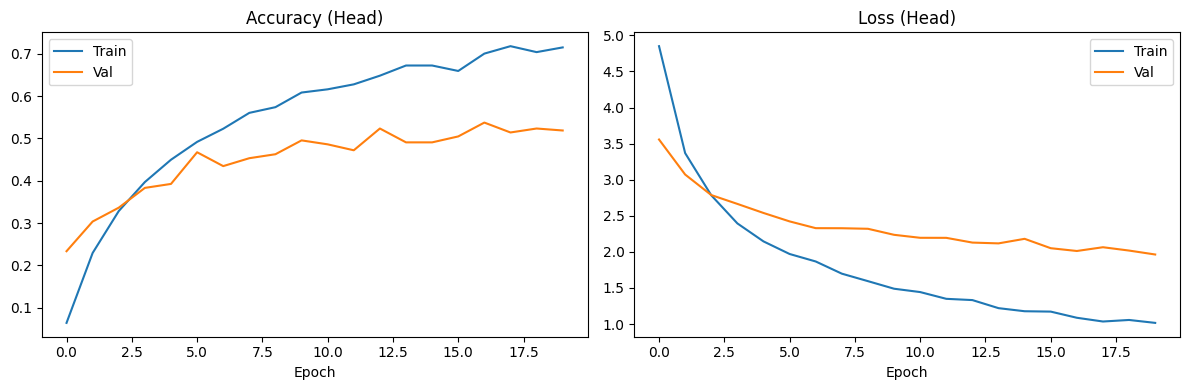

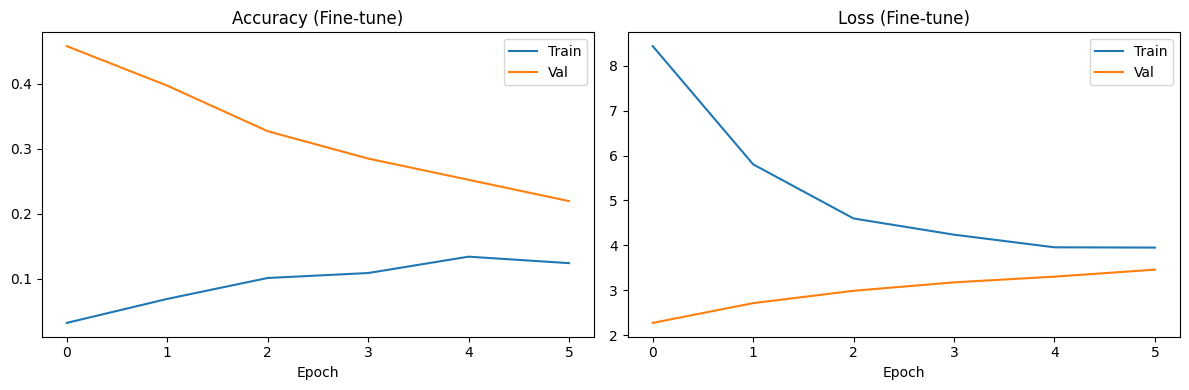

In [12]:
def plot_curves(history_dict, title_suffix=""):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history_dict['accuracy'], label='Train')
    plt.plot(history_dict['val_accuracy'], label='Val')
    plt.title(f"Accuracy {title_suffix}"); plt.xlabel("Epoch"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history_dict['loss'], label='Train')
    plt.plot(history_dict['val_loss'], label='Val')
    plt.title(f"Loss {title_suffix}"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout(); plt.show()

# Load from JSON if in-memory not available
for tag, path in [("Head", f'{DRIVE_ROOT}/history_head.json'),
                  ("Fine-tune", f'{DRIVE_ROOT}/history_finetune.json')]:
    if os.path.exists(path):
        with open(path) as f:
            hist = json.load(f)
        plot_curves(hist, title_suffix=f"({tag})")


In [13]:
# Load both, compare on validation set
head_model = tf.keras.models.load_model(DRIVE_HEAD_MODEL)
ft_model = tf.keras.models.load_model(DRIVE_FT_MODEL)

head_loss, head_acc = head_model.evaluate(val_gen, verbose=0)
ft_loss, ft_acc = ft_model.evaluate(val_gen, verbose=0)

print(f"Head-only model:  val_acc = {head_acc:.4f}")
print(f"Fine-tuned model: val_acc = {ft_acc:.4f}")

if head_acc > ft_acc:
    print("→ Head-only is better. Using that for evaluation.")
    import shutil
    shutil.copy(DRIVE_HEAD_MODEL, DRIVE_FT_MODEL)  # overwrite FT with head
    print(" Head model copied over FT checkpoint. Now Cell 26 will use it.")
else:
    print("→ Fine-tuned is better. Keeping it.")

Head-only model:  val_acc = 0.5374
Fine-tuned model: val_acc = 0.5374
→ Fine-tuned is better. Keeping it.


## 10. Evaluation, saving every metric to Drive

For research paper, every result to be cited is saved as JSON/CSV so it can be reloaded later without retraining.

In [20]:
# using the best fine-tuned checkpoint
if os.path.exists(DRIVE_FT_MODEL):
    model = tf.keras.models.load_model(DRIVE_FT_MODEL)
    print(f"Loaded best fine-tuned model.")

test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy (micro): {test_acc*100:.2f}%")


Loaded best fine-tuned model.
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.5701 - loss: 2.1718

Test loss: 2.1718
Test accuracy (micro): 57.01%


In [21]:
# Predictions on test set
test_gen.reset()
y_pred_proba = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = test_gen.classes

# Restrict to classes present in y_true (avoids sklearn warnings)
present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])).tolist())
present_names  = [CLASS_LIST[i] for i in present_labels]

# Classification report
report_str = classification_report(
    y_true, y_pred,
    labels=present_labels,
    target_names=present_names,
    zero_division=0
)
print(report_str)

# Machine-readable version for the paper
report_dict = classification_report(
    y_true, y_pred,
    labels=present_labels,
    target_names=present_names,
    zero_division=0,
    output_dict=True
)

# Macro-F1 is the metric that ACTUALLY reflects imbalanced-multi-class performance
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"\nMacro-F1: {macro_f1:.4f}")
print(f"Weighted-F1: {weighted_f1:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step
                                  precision    recall  f1-score   support

               andean guan_sound       1.00      0.33      0.50         6
            andean tinamou_sound       0.00      0.00      0.00         4
    australian brushturkey_sound       1.00      0.50      0.67         4
          band-tailed guan_sound       0.00      0.00      0.00         2
         bartletts tinamou_sound       0.50      0.50      0.50         2
                baudo guan_sound       0.00      0.00      0.00         2
              bearded guan_sound       0.00      0.00      0.00         0
        berlepschs tinamou_sound       0.75      1.00      0.86         3
            biak scrubfowl_sound       0.50      1.00      0.67         1
             black tinamou_sound       1.00      1.00      1.00         2
  black-billed brushturkey_sound       1.00      0.67      0.80         3
 black-fronted piping guan_sound       0.00      0.00      0.00      

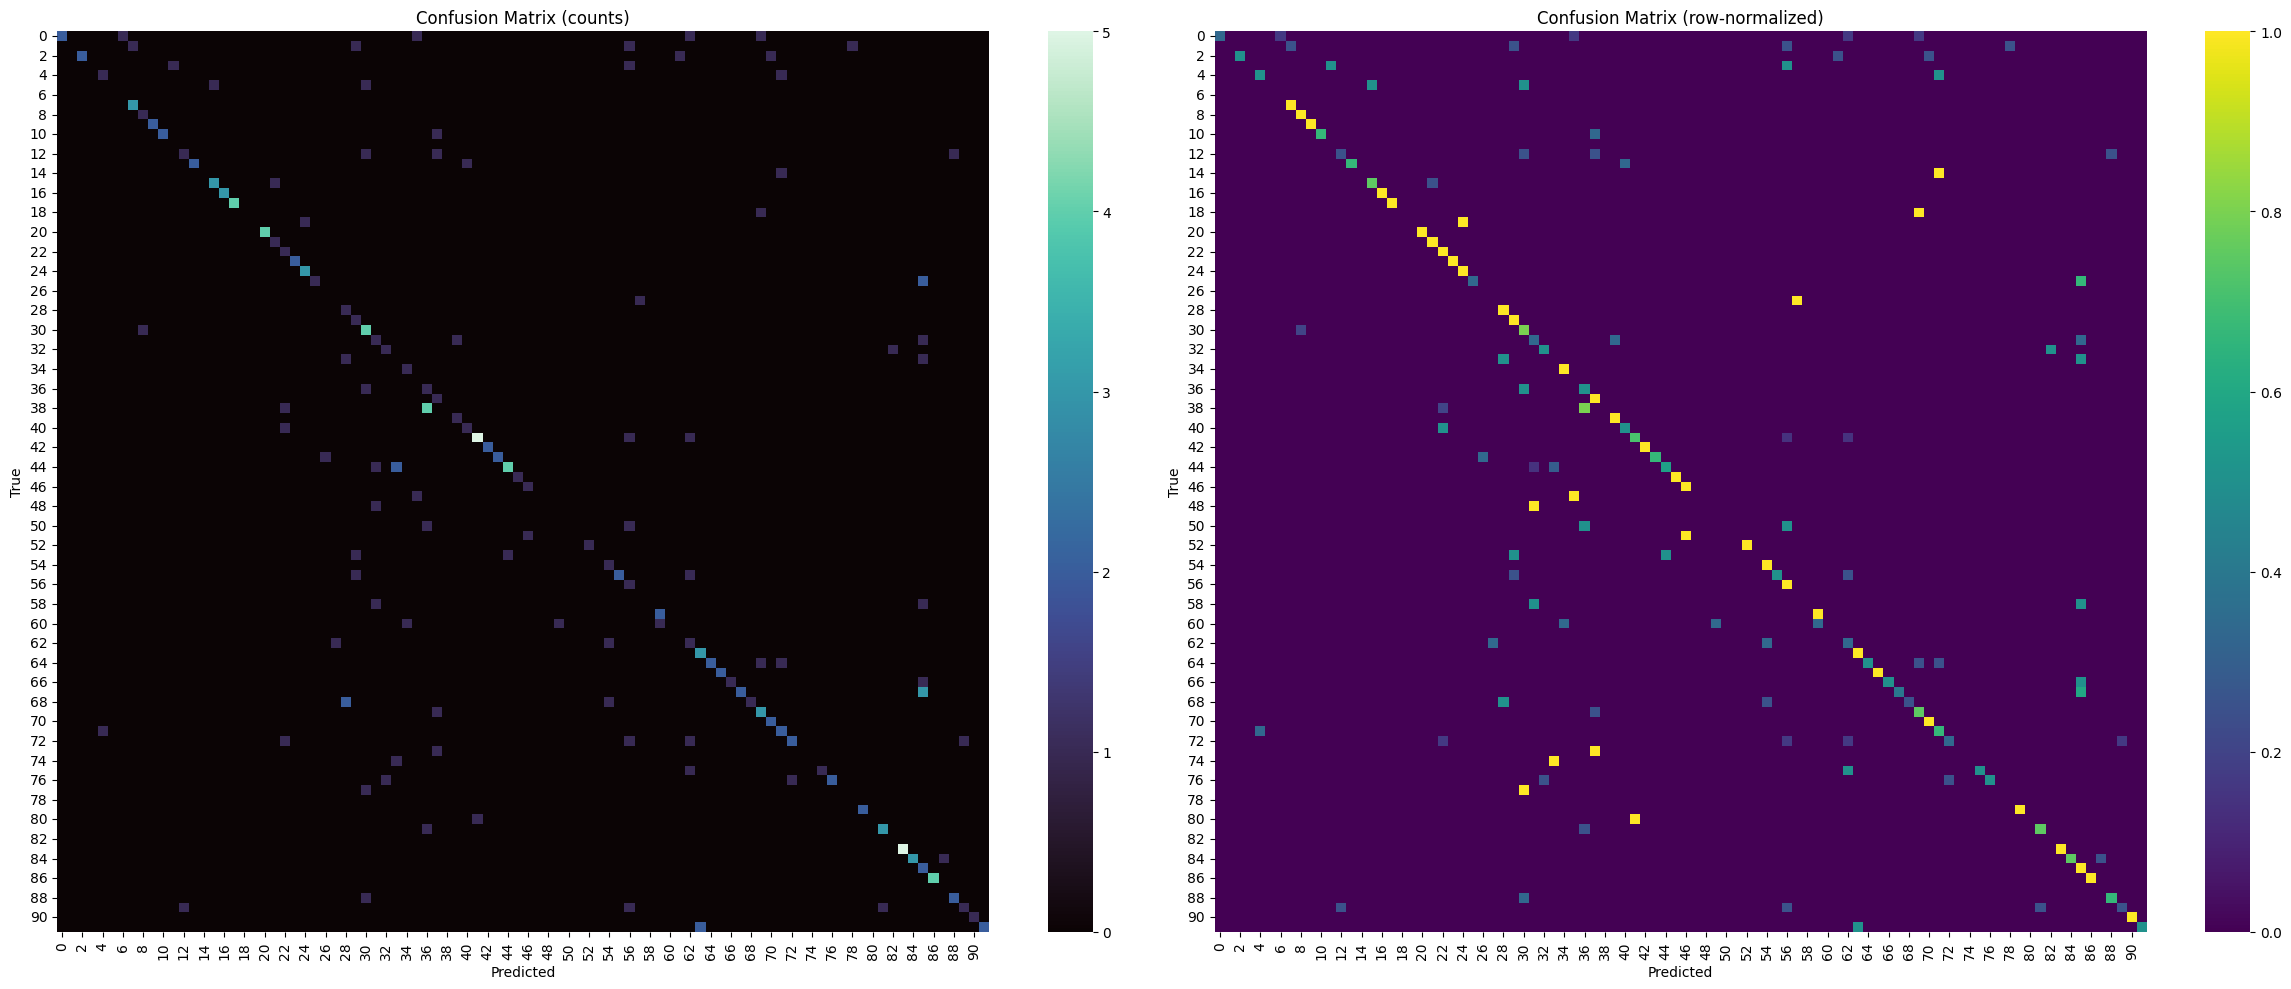

 Confusion matrix saved to Drive.


In [22]:
# Confusion matrix (normalized, much more readable than raw counts for 100+ classes)
cm = confusion_matrix(y_true, y_pred, labels=present_labels)
cm_norm = confusion_matrix(y_true, y_pred, labels=present_labels, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(24, 10))
sns.heatmap(cm, cmap="mako", ax=ax[0], cbar=True)
ax[0].set_title("Confusion Matrix (counts)")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")

sns.heatmap(cm_norm, cmap="viridis", ax=ax[1], cbar=True, vmin=0, vmax=1)
ax[1].set_title("Confusion Matrix (row-normalized)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f" Confusion matrix saved to Drive.")


In [24]:
# Per-species accuracy, critical for paper's error-analysis section
row_sums = cm.sum(axis=1)
per_class_acc = np.where(row_sums > 0, cm.diagonal() / np.maximum(row_sums, 1), 0.0)

df_acc = pd.DataFrame({
    "species": present_names,
    "n_test": row_sums,
    "accuracy": per_class_acc,
    "precision": [report_dict[n]['precision'] for n in present_names],
    "recall":    [report_dict[n]['recall']    for n in present_names],
    "f1":        [report_dict[n]['f1-score']  for n in present_names],
}).sort_values("accuracy", ascending=False).reset_index(drop=True)

df_acc.to_csv(DRIVE_REPORT_CSV, index=False)
print(f" Per-species metrics saved: {DRIVE_REPORT_CSV}")

print("\nTop 10 best classified:")
print(df_acc.head(10).to_string(index=False))
print("\nBottom 10 (hardest — good candidates for paper's error analysis):")
print(df_acc.tail(10).to_string(index=False))

macro_acc = df_acc["accuracy"].mean()
print(f"\nMacro Accuracy: {macro_acc*100:.2f}%")


 Per-species metrics saved: /content/drive/MyDrive/BirdSound114/per_species_accuracy.csv

Top 10 best classified:
                         species  n_test  accuracy  precision  recall       f1
            biak scrubfowl_sound       1       1.0       0.50     1.0 0.666667
             black tinamou_sound       2       1.0       1.00     1.0 1.000000
        berlepschs tinamou_sound       3       1.0       0.75     1.0 0.857143
          chaco chachalaca_sound       4       1.0       1.00     1.0 1.000000
      collared brushturkey_sound       3       1.0       0.75     1.0 0.857143
chestnut-winged chachalaca_sound       4       1.0       1.00     1.0 1.000000
             choco tinamou_sound       1       1.0       0.25     1.0 0.400000
         cinereous tinamou_sound       2       1.0       1.00     1.0 1.000000
                cauca guan_sound       3       1.0       1.00     1.0 1.000000
           chilean tinamou_sound       1       1.0       0.50     1.0 0.666667

Bottom 10 (harde

In [25]:
# Bundled every headline metric into one JSON, the source of truth for the paper
final_metrics = {
    "config": {
        "seed": SEED,
        "img_size": list(IMG_SIZE),
        "batch_size": BATCH,
        "sample_rate": SR,
        "n_mels": N_MELS,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
        "epochs_head": EPOCHS_HEAD,
        "epochs_finetune": EPOCHS_FT,
        "lr_head": LR_HEAD,
        "lr_finetune": LR_FT,
    },
    "dataset": {
        "num_classes": NUM_CLASSES,
        "n_train": len(train_gen.filenames),
        "n_val": len(val_gen.filenames),
        "n_test": len(test_gen.filenames),
    },
    "results": {
        "test_loss": float(test_loss),
        "test_accuracy_micro": float(test_acc),
        "test_accuracy_macro": float(macro_acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
    },
    "class_weights_active": {
        "min": float(class_weights_array.min()),
        "max": float(class_weights_array.max()),
    }
}

with open(DRIVE_METRICS, 'w') as f:
    json.dump(final_metrics, f, indent=2)

print(json.dumps(final_metrics, indent=2))
print(f"\n All metrics saved to {DRIVE_METRICS}")

# Save the final model in Keras format too
model.save(DRIVE_FINAL_MODEL)
print(f" Final model saved: {DRIVE_FINAL_MODEL}")


{
  "config": {
    "seed": 42,
    "img_size": [
      224,
      224
    ],
    "batch_size": 16,
    "sample_rate": 16000,
    "n_mels": 128,
    "n_fft": 2048,
    "hop_length": 512,
    "min_samples_per_class": 4,
    "epochs_head": 20,
    "epochs_finetune": 15,
    "lr_head": 0.001,
    "lr_finetune": 1e-05
  },
  "dataset": {
    "num_classes": 102,
    "n_train": 1708,
    "n_val": 214,
    "n_test": 214
  },
  "results": {
    "test_loss": 2.171835422515869,
    "test_accuracy_micro": 0.5700934529304504,
    "test_accuracy_macro": 0.5079968944099379,
    "macro_f1": 0.4510776662950576,
    "weighted_f1": 0.5631805370123126
  },
  "class_weights_active": {
    "min": 0.5980392156862745,
    "max": 5.5816993464052285
  }
}

 All metrics saved to /content/drive/MyDrive/BirdSound114/final_metrics.json
 Final model saved: /content/drive/MyDrive/BirdSound114/final_bird_classifier.keras


## 11. Prediction on new audio

In [26]:
import cv2

# Load class map (works even in a fresh session)
with open(DRIVE_CLASS_MAP) as f:
    class_indices = json.load(f)
idx_to_class = {v: k for k, v in class_indices.items()}
CLASS_LIST = list(class_indices.keys())

def predict_audio(filepath, top_k=5):
    print(f"\nPredicting: {filepath}")
    y, sr = librosa.load(filepath, sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    img = cv2.resize(mel_norm, IMG_SIZE)
    img = np.stack([img, img, img], axis=-1)
    img = np.expand_dims(img, axis=0).astype(np.float32)

    preds = model.predict(img, verbose=0)[0]
    top_idx = preds.argsort()[::-1][:top_k]

    print("\nTop predictions:")
    for i in top_idx:
        print(f"  {idx_to_class[i]:<40s} {preds[i]*100:.2f}%")
    return [(idx_to_class[i], float(preds[i])) for i in top_idx]

# Example:
predict_audio("/content/t1.mp3")



Predicting: /content/t1.mp3

Top predictions:
  choco tinamou_sound                      99.97%
  emu_sound                                0.01%
  white-bellied nothura_sound              0.01%
  slaty-breasted tinamou_sound             0.00%
  thicket tinamou_sound                    0.00%


[('choco tinamou_sound', 0.9996541738510132),
 ('emu_sound', 5.505587614607066e-05),
 ('white-bellied nothura_sound', 5.186117050470784e-05),
 ('slaty-breasted tinamou_sound', 4.7938956413418055e-05),
 ('thicket tinamou_sound', 2.8003963961964473e-05)]

## Notes for the research paper

The notebook now saves everything you need for an ablation-driven paper:

- `training_history.json` (head + fine-tune) → plot Fig 1 (learning curves)
- `confusion_matrix.png` → Fig 2
- `per_species_accuracy.csv` → Table 2 (top/bottom species) + Fig 3 (histogram of per-class accuracy)
- `final_metrics.json` → Table 1 (headline results)

**To run an ablation** (e.g., no class weights), change the config at the top, delete the corresponding checkpoint from Drive, and rerun. Everything else regenerates automatically.

**Suggested ablations for the paper** (fills the research gap for imbalanced bird sound classification):

1. **With vs without class weights** — quantify how much imbalance handling matters
2. **With vs without augmentation** — set `train_aug = test_aug`
3. **Frozen vs fine-tuned base** — skip Cell 11 for the frozen-only variant
4. **MobileNetV2 vs EfficientNet-B0** — swap the base in `build_model`
5. **Different `n_mels` (64, 128, 256)** — spectrogram resolution study

Each run overwrites `final_metrics.json` — copy it to a variant name before running the next:
```python
shutil.copy(DRIVE_METRICS, f'{DRIVE_ROOT}/metrics_variant_no_class_weights.json')
```


In [27]:
# Check if the true species is in the class list at all
target = "white-winged tinamou"

matches = [c for c in CLASS_LIST if "tinamou" in c.lower()]
print(f"Species containing 'tinamou' in class list: {matches}")

exact = [c for c in CLASS_LIST if "white" in c.lower() and "tinamou" in c.lower()]
print(f"White-winged tinamou variants: {exact}")

if not matches:
    print("\n TINAMOU IS NOT IN CLASS LIST AT ALL.")
    print("It was dropped by the MIN_SAMPLES_PER_CLASS=4 filter.")
    print("The model literally CANNOT predict it — it has never seen this species.")

Species containing 'tinamou' in class list: ['andean tinamou_sound', 'bartletts tinamou_sound', 'berlepschs tinamou_sound', 'black tinamou_sound', 'black-capped tinamou_sound', 'brazilian tinamou_sound', 'brown tinamou_sound', 'brushland tinamou_sound', 'chilean tinamou_sound', 'choco tinamou_sound', 'cinereous tinamou_sound', 'curve-billed tinamou_sound', 'dwarf tinamou_sound', 'elegant crested tinamou_sound', 'great tinamou_sound', 'grey tinamou_sound', 'grey-legged tinamou_sound', 'highland tinamou_sound', 'hooded tinamou_sound', 'huayco tinamou_sound', 'little tinamou_sound', 'ornate tinamou_sound', 'pale-browed tinamou_sound', 'puna tinamou_sound', 'quebracho crested tinamou_sound', 'red-legged tinamou_sound', 'red-winged tinamou_sound', 'rusty tinamou_sound', 'slaty-breasted tinamou_sound', 'small-billed tinamou_sound', 'solitary tinamou_sound', 'taczanowskis tinamou_sound', 'tataupa tinamou_sound', 'tawny-breasted tinamou_sound', 'thicket tinamou_sound', 'undulated tinamou_sound